# Feature Engineering and Regression Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


## 1. Date Feature Engineering

In [2]:
df = pd.read_csv('q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


## 2. Temporal Train-Test Split

In [3]:
# Sort by date
df = df.sort_values('transaction_date')

# Split index
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]


A random split is inappropriate for time-series data because it can leak future information into the training set.
Using a temporal split ensures the model is evaluated on unseen future data, simulating real-world prediction.

## 3. Preprocessing Pipeline

In [4]:
# Features and target
target = 'items_sold'

X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


## 4. Model Training and Evaluation


Linear Regression
RMSE: 27.12145116489062
MAE: 21.05292667458839


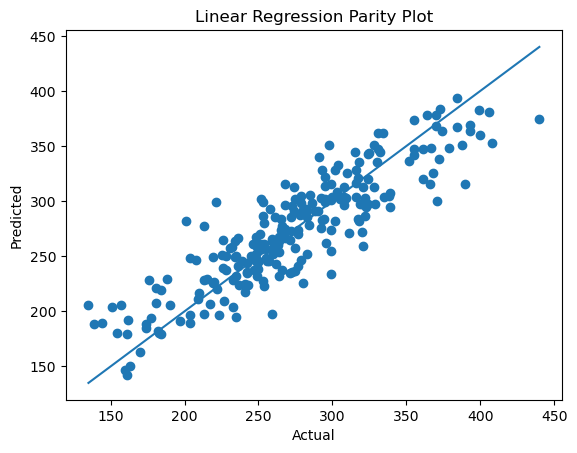


Random Forest
RMSE: 30.840947138774233
MAE: 24.306125


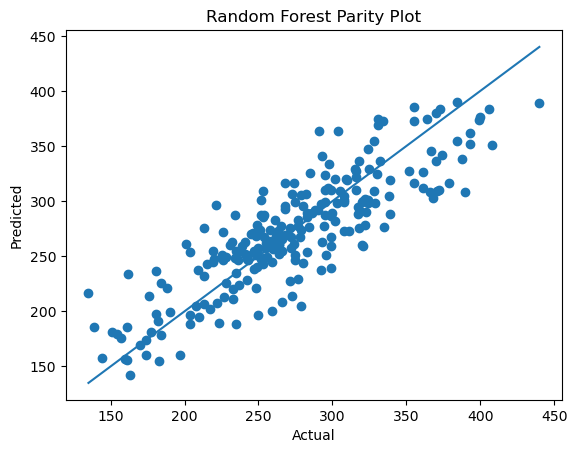

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = mean_squared_error(y_test, preds, squared=False)
    mae = mean_absolute_error(y_test, preds)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

    # Parity plot
    plt.figure()
    plt.scatter(y_test, preds)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} Parity Plot")
    plt.show()

    results[name] = pipe


In [6]:
# Feature Importance (Random Forest)
rf_model = results["Random Forest"]

# Get feature names
ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(cat_features)

importances = rf_model.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(5)


,feature,importance
2,is_festival,0.173413
18,store_size_small,0.166752
15,location_type_urban,0.108505
6,day_of_week,0.080552
1,is_weekend,0.067103
